# Cart-pole: stabilizing an unstable equilibrium

The model is the declared cart-pole from [`models/cart_pole.py`](models/cart_pole.py):
an inverted pendulum on a cart, four states, one force input, starting from a
40-degree tilt. The upright target is an unstable equilibrium, the regime
where short-horizon NMPC visibly fails and terminal machinery earns its keep.
Two cases of the same model. Case 1 runs five sampling steps with the
infinite-horizon terminal segment (`drto.infinite_horizon`,
[Dinh et al. 2025](https://doi.org/10.1016/j.jprocont.2025.103565)) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs fifty steps of plain finite horizon with the
terminal cost live. The pole is fast relative to the one-second sampling, so
both cases discretize with five collocation points per element.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import pyomo_pounce  # registers pounce with the native factory
from pyomo.contrib.solver.common.factory import SolverFactory
import drto
from models.cart_pole import cart_pole
from drto import plot_states, plot_controls, plot_stage_cost

m1 = cart_pole(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=5, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
SolverFactory("pounce").solve(m1, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.10.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmplgs4iuwv\unknown9kmwopo0.nl...
Parsed



Number of Iterations....: 15

                                   (scaled)                 (unscaled)
Objective...............:   5.8259174334481034e-01    2.6077284235805473e+03
Dual infeasibility......:   2.3896653507485739e-11    1.0696338094692884e-07
Constraint violation....:   3.2771265228348642e-09    1.5021241495105642e-07
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.6974195762806260e-09    1.2073871248165611e-05
Overall NLP error.......:   3.2771265228348642e-09    1.2073871248165611e-05


Number of objective function evaluations             = 16
Number of objective gradient evaluations             = 16
Number of equality constraint evaluations            = 16
Number of inequality constraint evaluations          = 16
Number of equality constraint Jacobian evaluations   = 16
Number of inequality constraint Jacobian evaluations = 16
Number of Lagrangian Hessian evaluations             = 16
Total seconds in POUNCE    

In [2]:
drto.info(m1)

<drto registry>
states: 4, controls: 1
declarations:
  horizon: t (ContinuousSet, 26 points)
  states: x (free), x_dot (free), theta (free), theta_dot (free)
  dynamics: dx[t]  ==  x_dot[t]  for t in t
  dynamics: dx_dot[t]  ==  (m_p*g*sin(theta[t])*cos(theta[t]) - (1 + kJ)*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t]) - b*x_dot[t]))/(m_p*cos(theta[t])**2 - (1 + kJ)*m_c)  for t in t
  dynamics: dtheta[t]  ==  theta_dot[t]  for t in t
  dynamics: dtheta_dot[t]  ==  (m_c*g*sin(theta[t]) - cos(theta[t])*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t])))/((1 + kJ)*m_c*l - m_p*l*cos(theta[t])**2)  for t in t
  controls: F (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  (theta[t] - theta_ss)**2/theta_scale**2 + 0.01*(x[t] - x_ss)**2 + 0.01*(x_dot[t] - x_dot_ss)**2 + 0.01*(theta_dot[t] - theta_dot_ss)**2/theta_scale**2 + 0.1*(F[t] - F_ss)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  (theta[5] - theta_ss)**2/theta_scale**2 + 0.01*(x[5] - x_ss)**2 + 0.01*(x_dot[5] - x_dot_ss)**2 + 0.01*(theta_dot[5] - theta_dot_ss)**2/theta_scale**2
  initial conditions: x[0]  ==  x_hat
  initial conditions: x_dot[0]  ==  x_dot_hat
  initial conditions: theta[0]  ==  theta_hat
  initial conditions: theta_dot[0]  ==  theta_dot_hat
  steady-state targets: x_ss (of x), x_dot_ss (of x_dot), theta_ss (of theta), theta_dot_ss (of theta_dot)
  steady-state control targets: F_ss (of F)
transformations:
  drto.infinite_horizon: segment=3 elements x 5 Legendre points, beta=1.2, gamma=0.01563827, profile=collocation, horizon=kept, infinite tail appended, terminal_cost=terminal deactivated (the tail owns it), terminal=soft pin z(tau=1)=z_s on 4 states, mu=1000.0
  drto.parameterize: profiles=F (piecewise_constant)
  drto.build_objective: objective=sum of 36 weighted cost terms

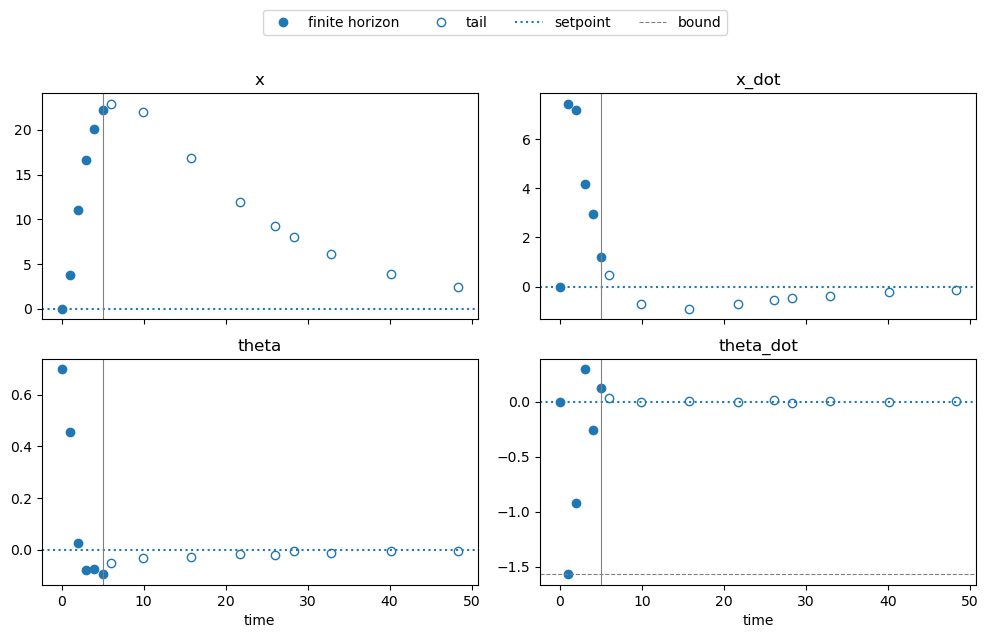

In [3]:
plot_states(m1);

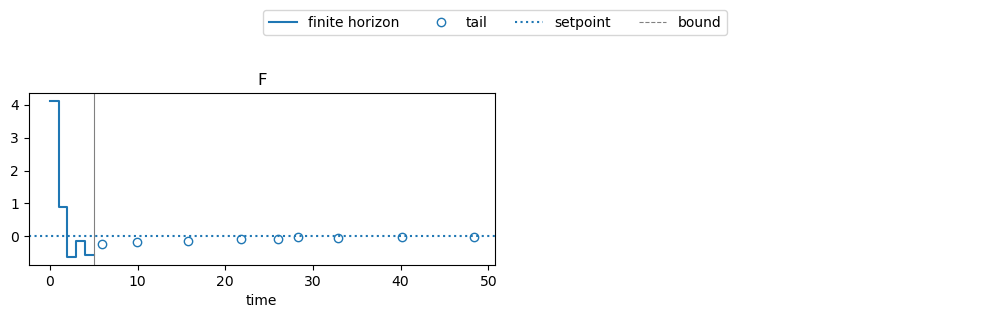

In [4]:
plot_controls(m1);

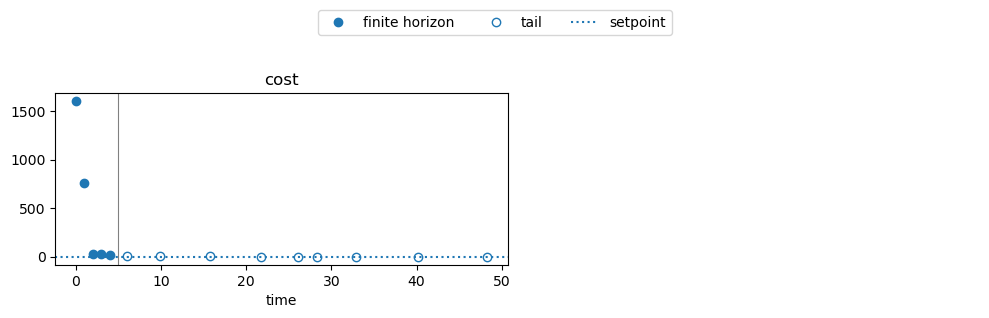

In [5]:
plot_stage_cost(m1);

## Case 2: fifty samples, finite horizon with the terminal cost

In [6]:
m2 = cart_pole(N=50)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=50, ncp=5, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
SolverFactory("pounce").solve(m2, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.10.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpcnu0y99m\unknownqnjk4oo9.nl...
Parsed

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpcnu0y99m\unknownqnjk4oo9.sol


  23 -4.5444712e+03 9.48e+02 4.67e+02   -1.0 2.31e+03      - 1.49e-01 6.09e-01h  1
  24 -5.6057708e+02 5.35e+02 3.90e+02   -1.0 9.41e+02      - 4.00e-02 4.37e-01h  1
  25  1.9198174e+03 2.57e+02 3.13e+02   -1.0 5.33e+02      - 2.45e-01 5.20e-01h  1
  26  3.5975233e+03 3.55e+01 4.58e+02   -1.0 2.57e+02      - 6.23e-02 1.00e+00h  1
  27  3.1856407e+03 2.55e+01 4.07e+02   -1.0 6.92e+01      - 1.18e-01 1.00e+00f  1
  28  2.4749926e+03 4.28e+01 3.22e+02   -1.0 9.43e+01      - 2.05e-01 1.00e+00f  1
  29  2.4245947e+03 3.87e+01 2.11e+02   -1.0 7.68e+01      - 3.44e-01 1.00e+00f  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  30  2.5874731e+03 5.00e-01 1.47e+01   -1.0 3.84e+01      - 9.30e-01 1.00e+00h  1
  31  2.5894820e+03 5.03e-04 1.26e-05   -1.0 4.89e-01      - 1.00e+00 1.00e+00h  1
  32  2.5893878e+03 2.43e-05 1.60e-05   -2.5 5.88e-02      - 1.00e+00 1.00e+00f  1
  33  2.5893851e+03 2.00e-08 1.26e-08   -3.8 1.70e-03      - 1.00e+00 1.00e+00f  1
  34

In [7]:
drto.info(m2)

<drto registry>
states: 4, controls: 1
declarations:
  horizon: t (ContinuousSet, 251 points)
  states: x (free), x_dot (free), theta (free), theta_dot (free)
  dynamics: dx[t]  ==  x_dot[t]  for t in t
  dynamics: dx_dot[t]  ==  (m_p*g*sin(theta[t])*cos(theta[t]) - (1 + kJ)*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t]) - b*x_dot[t]))/(m_p*cos(theta[t])**2 - (1 + kJ)*m_c)  for t in t
  dynamics: dtheta[t]  ==  theta_dot[t]  for t in t
  dynamics: dtheta_dot[t]  ==  (m_c*g*sin(theta[t]) - cos(theta[t])*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t])))/((1 + kJ)*m_c*l - m_p*l*cos(theta[t])**2)  for t in t
  controls: F (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  (theta[t] - theta_ss)**2/theta_scale**2 + 0.01*(x[t] - x_ss)**2 + 0.01*(x_dot[t] - x_dot_ss)**2 + 0.01*(theta_dot[t] - theta_dot_ss)**2/theta_scale**2 + 0.1*(F[t] - F_ss)**2  for t in sorted(t)[:-1]
  terminal cost: term  ==  (theta[50] - theta_ss)**2/theta_scale**2 + 0.01*(x[50] - x_ss)**2 + 0.01*(x_dot[50] - x_dot_ss)**2 + 0.01*(theta_dot[50] - theta_dot_ss)**2/theta_scale**2
  initial conditions: x[0]  ==  x_hat
  initial conditions: x_dot[0]  ==  x_dot_hat
  initial conditions: theta[0]  ==  theta_hat
  initial conditions: theta_dot[0]  ==  theta_dot_hat
  steady-state targets: x_ss (of x), x_dot_ss (of x_dot), theta_ss (of theta), theta_dot_ss (of theta_dot)
  steady-state control targets: F_ss (of F)
transformations:
  drto.parameterize: profiles=F (piecewise_constant)
  drto.build_objective: objective=sum of 51 weighted cost terms

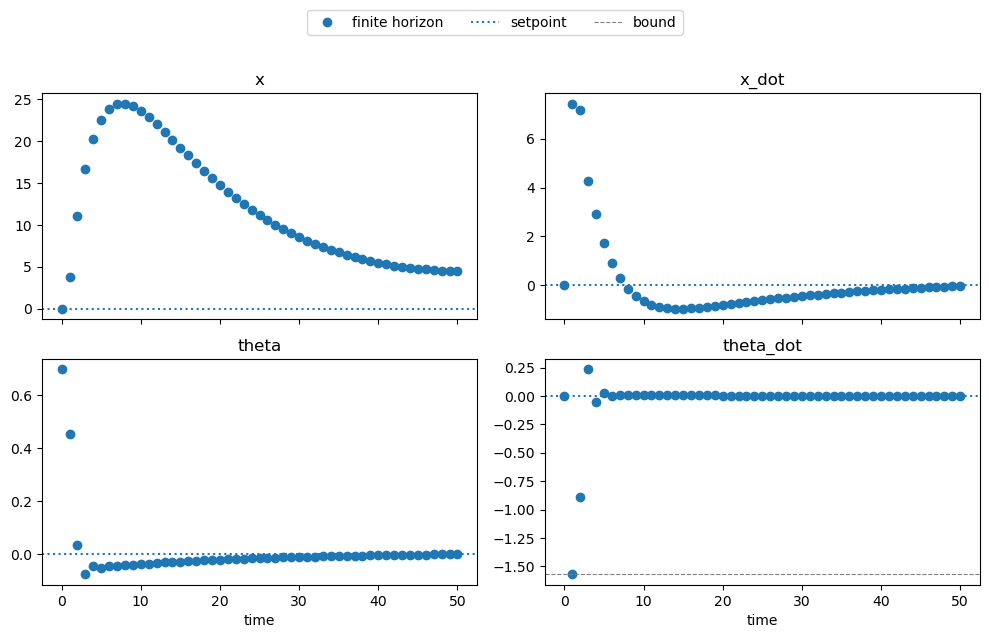

In [8]:
plot_states(m2);

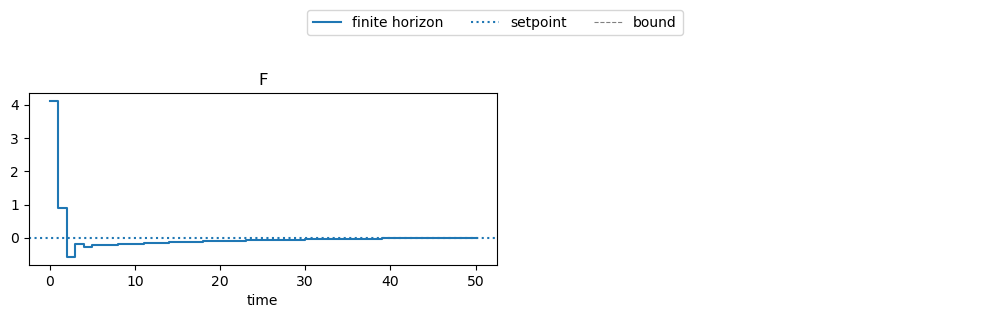

In [9]:
plot_controls(m2);

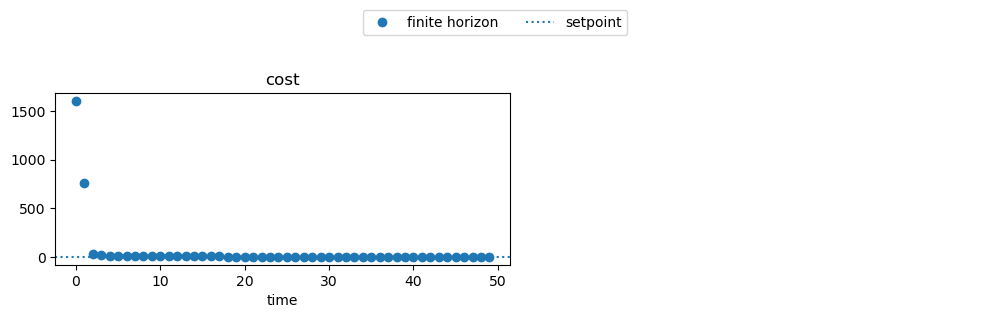

In [10]:
plot_stage_cost(m2);